In [1]:
# 05 – Bevoelkerungsabdeckung
# Vertiefende Analyse: Wer ist unterversorgt?
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROCESSED = Path('..') / 'data' / 'processed'
OUTPUTS   = Path('..') / 'outputs' / 'maps'
OUTPUTS.mkdir(parents=True, exist_ok=True)

gdf = gpd.read_file(PROCESSED / 'gemeinden_mit_distanz.geojson').to_crs(2056)
print('Gemeinden geladen:', len(gdf))
print('Spalten:', [c for c in gdf.columns if c != 'geometry'])
print('Gesamtbevoelkerung:', f"{gdf['einwohnerzahl'].sum():,.0f}")

Gemeinden geladen: 2123
Spalten: ['bfs_nummer', 'name', 'einwohnerzahl', 'gem_flaeche', 'kantonsnummer', 'min_distanz_m', 'versorgung', 'apotheken_anzahl']
Gesamtbevoelkerung: 9,095,329


In [2]:
# 2) Versorgungskategorien und Bevoelkerungsanteil
bins   = [0, 1000, 3000, 5000, 10000, float('inf')]
labels = ['< 1 km', '1–3 km', '3–5 km', '5–10 km', '> 10 km']
gdf['distanz_kat'] = pd.cut(gdf['min_distanz_m'], bins=bins, labels=labels)

total_bev = gdf['einwohnerzahl'].sum()
summary = gdf.groupby('distanz_kat', observed=True).agg(
    gemeinden=('bfs_nummer', 'count'),
    bevoelkerung=('einwohnerzahl', 'sum')
).reset_index()
summary['anteil_pct'] = (summary['bevoelkerung'] / total_bev * 100).round(1)

print('Versorgungskategorien:')
print(summary.to_string(index=False))
print()
unterversorgt = gdf[gdf['min_distanz_m'] > 5000]
print(f'Unterversorgt (> 5km): {len(unterversorgt)} Gemeinden, '
      f'{unterversorgt["einwohnerzahl"].sum():,.0f} Personen '
      f'({unterversorgt["einwohnerzahl"].sum()/total_bev*100:.1f}%)')

Versorgungskategorien:
distanz_kat  gemeinden  bevoelkerung  anteil_pct
     < 1 km        319       4089501        45.0
     1–3 km        693       2955077        32.5
     3–5 km        596       1218269        13.4
    5–10 km        431        705376         7.8
    > 10 km         84        127106         1.4

Unterversorgt (> 5km): 515 Gemeinden, 832,482 Personen (9.2%)


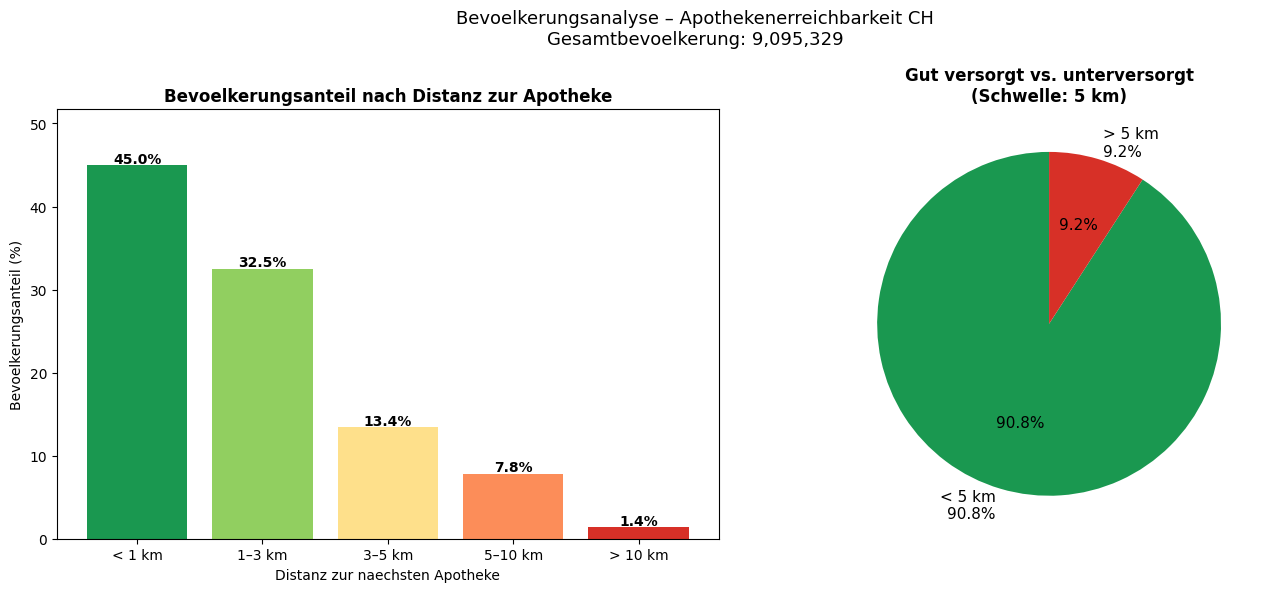

Gespeichert: ..\outputs\maps\05_bevoelkerungsabdeckung.png


In [3]:
# 3) Visualisierung: Bevoelkerung nach Versorgungskategorie
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#1a9850','#91cf60','#fee08b','#fc8d59','#d73027']

# Balken: Bevoelkerungsanteil
ax = axes[0]
bars = ax.bar(summary['distanz_kat'], summary['anteil_pct'], color=colors)
for bar, val in zip(bars, summary['anteil_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Bevoelkerungsanteil nach Distanz zur Apotheke', fontsize=12, fontweight='bold')
ax.set_xlabel('Distanz zur naechsten Apotheke')
ax.set_ylabel('Bevoelkerungsanteil (%)')
ax.set_ylim(0, summary['anteil_pct'].max() * 1.15)

# Pie: Gut versorgt vs unterversorgt
ax2 = axes[1]
gut  = gdf[gdf['min_distanz_m'] <= 5000]['einwohnerzahl'].sum()
schlecht = gdf[gdf['min_distanz_m'] > 5000]['einwohnerzahl'].sum()
ax2.pie([gut, schlecht],
        labels=[f'< 5 km\n{gut/total_bev*100:.1f}%', f'> 5 km\n{schlecht/total_bev*100:.1f}%'],
        colors=['#1a9850','#d73027'], autopct='%1.1f%%', startangle=90,
        textprops={'fontsize':11})
ax2.set_title('Gut versorgt vs. unterversorgt\n(Schwelle: 5 km)', fontsize=12, fontweight='bold')

plt.suptitle(f'Bevoelkerungsanalyse – Apothekenerreichbarkeit CH\n'
             f'Gesamtbevoelkerung: {total_bev:,.0f}', fontsize=13)
plt.tight_layout()
out = OUTPUTS / '05_bevoelkerungsabdeckung.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)

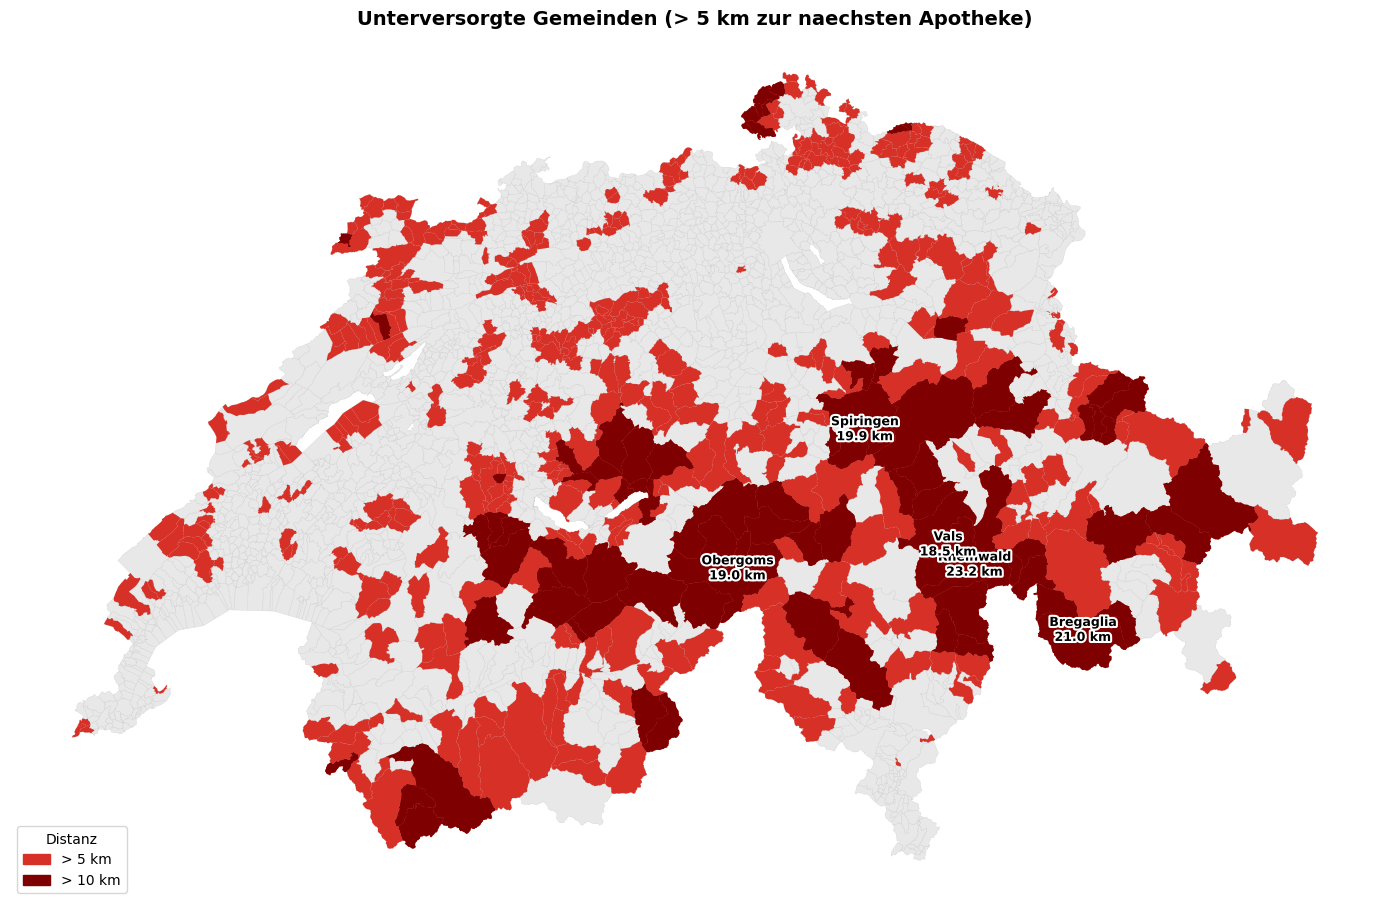

Karte gespeichert: ..\outputs\maps\05_unterversorgte_gemeinden.png

Top 10 schlechtestversorgte Gemeinden:
     name  einwohnerzahl  distanz_km
Rheinwald            570        23.2
Bregaglia           1591        21.0
Spiringen            881        19.9
 Obergoms            663        19.0
     Vals            958        18.5
  Mesocco           1414        18.5
   Zernez           1592        18.0
    Avers            169        17.6
Göschenen            458        17.0
   Sufers            147        16.9


In [4]:
# 4) Karte: Unterversorgte Gemeinden hervorgehoben
import matplotlib.patheffects as PathEffects
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))

# Alle Gemeinden grau (Hintergrund)
gdf.plot(ax=ax, color='#e8e8e8', edgecolor='#cccccc', linewidth=0.2)

# Unterversorgte rot (> 5km)
gdf[gdf['min_distanz_m'] > 5000].plot(
    ax=ax, color='#d73027', edgecolor='none'
)

# Extrem unterversorgte dunkelrot (> 10km)
gdf[gdf['min_distanz_m'] > 10000].plot(
    ax=ax, color='#7f0000', edgecolor='none'
)

# Gemeinde mit groesster Distanz beschriften (mit Halo-Effekt)
worst = gdf.nlargest(5, 'min_distanz_m')
for _, row in worst.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    # Text-Objekt einer Variable zuweisen
    txt = ax.annotate(f"{row['name']}\n{row['min_distanz_m']/1000:.1f} km",
                      xy=(cx, cy), fontsize=9, ha='center',
                      color='black', fontweight='bold')
    # Weissen Rand (Halo) um den Text legen
    txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])

ax.set_title('Unterversorgte Gemeinden (> 5 km zur naechsten Apotheke)',
             fontsize=14, fontweight='bold')
ax.set_axis_off()

# Legende manuell erstellen, um die matplotlib-Warnung zu umgehen
patch_5km = mpatches.Patch(color='#d73027', label='> 5 km')
patch_10km = mpatches.Patch(color='#7f0000', label='> 10 km')
ax.legend(handles=[patch_5km, patch_10km], title='Distanz', loc='lower left', fontsize=10)

plt.tight_layout()
out = OUTPUTS / '05_unterversorgte_gemeinden.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()

print('Karte gespeichert:', out)
print('\nTop 10 schlechtestversorgte Gemeinden:')
print(gdf.nlargest(10, 'min_distanz_m')[['name','einwohnerzahl','min_distanz_m']]
      .assign(distanz_km=lambda d: (d['min_distanz_m']/1000).round(1))
      .drop(columns='min_distanz_m').to_string(index=False))

In [5]:
# 5) Ergebnisse speichern
summary.to_csv(PROCESSED / '05_versorgungskategorien.csv', index=False)
gdf[gdf['min_distanz_m'] > 5000][['bfs_nummer','name','einwohnerzahl','min_distanz_m']]\
    .to_csv(PROCESSED / '05_unterversorgte_gemeinden.csv', index=False)
print('Gespeichert:')
print('  05_versorgungskategorien.csv')
print('  05_unterversorgte_gemeinden.csv')

Gespeichert:
  05_versorgungskategorien.csv
  05_unterversorgte_gemeinden.csv
